# Week 3 – Day 1 Assignment
# Artificial Neural Networks (ANN)

**Objective:** Build a comprehensive practical understanding of ANN — from a single neuron to a full forward-propagation network, comparing a from-scratch NumPy implementation with a TensorFlow/Keras implementation, and finishing with a real classification task.

**Contents**
1. Import Libraries
2. Activation Functions from Scratch (NumPy)
3. Single Artificial Neuron
4. Forward Propagation (NumPy) — 2 → 3 → 1 network
5. Same ANN in TensorFlow/Keras
6. Activation Function Visualizations
7. Bonus: ANN on the Breast Cancer Wisconsin Dataset


## Task 1 — Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Dataset & evaluation utilities (used in Task 7)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)


I0000 00:00:1784579048.416625     616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784579048.417460     616 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784579048.496022     616 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784579050.325454     616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784579050.325836     616 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


NumPy version: 2.4.4
TensorFlow version: 2.21.0


## Task 2 — Activation Functions Implemented from Scratch (NumPy)

Each function is implemented mathematically using only NumPy, then plotted.

| Function | Formula |
|---|---|
| Binary Step | $f(x) = 1$ if $x \geq 0$ else $0$ |
| Sigmoid | $f(x) = \dfrac{1}{1+e^{-x}}$ |
| Tanh | $f(x) = \dfrac{e^x - e^{-x}}{e^x + e^{-x}}$ |
| ReLU | $f(x) = \max(0, x)$ |
| Leaky ReLU | $f(x) = x$ if $x>0$ else $\alpha x$ |
| ELU | $f(x) = x$ if $x>0$ else $\alpha(e^x - 1)$ |
| Softmax | $f(x_i) = \dfrac{e^{x_i}}{\sum_j e^{x_j}}$ |


In [2]:
def binary_step(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def softmax(x):
    # subtract max for numerical stability
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

# Quick sanity checks
test_vals = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print("Input:      ", test_vals)
print("Binary Step:", binary_step(test_vals))
print("Sigmoid:    ", np.round(sigmoid(test_vals), 3))
print("Tanh:       ", np.round(tanh(test_vals), 3))
print("ReLU:       ", relu(test_vals))
print("Leaky ReLU: ", np.round(leaky_relu(test_vals), 3))
print("ELU:        ", np.round(elu(test_vals), 3))
print("Softmax:    ", np.round(softmax(test_vals), 3), " (sums to", round(softmax(test_vals).sum(), 3), ")")


Input:       [-2.  -0.5  0.   0.5  2. ]
Binary Step: [0 0 1 1 1]
Sigmoid:     [0.119 0.378 0.5   0.622 0.881]
Tanh:        [-0.964 -0.462  0.     0.462  0.964]
ReLU:        [0.  0.  0.  0.5 2. ]
Leaky ReLU:  [-0.2  -0.05  0.    0.5   2.  ]
ELU:         [-0.865 -0.393  0.     0.5    2.   ]
Softmax:     [0.013 0.056 0.093 0.153 0.685]  (sums to 1.0 )


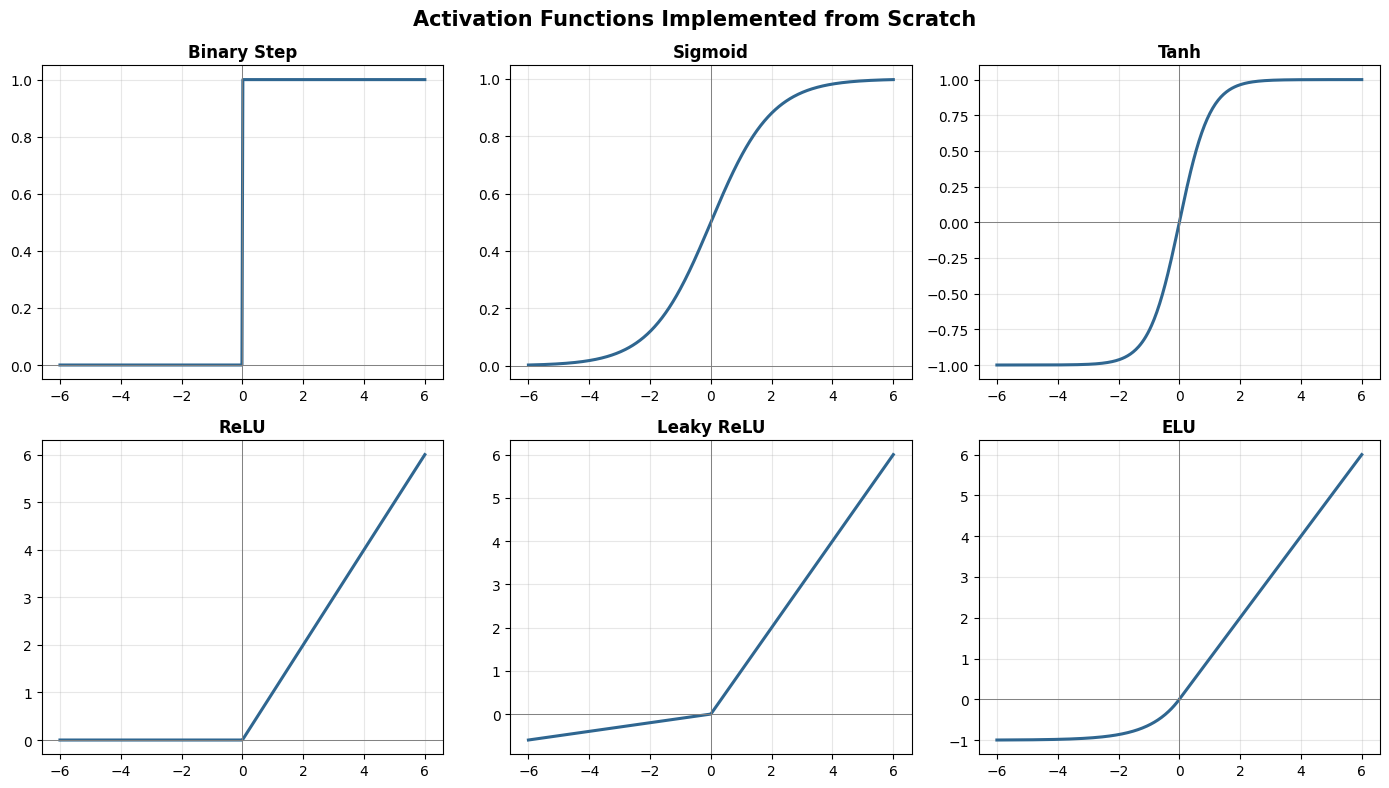

In [3]:
x = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
functions = {
    "Binary Step": binary_step(x),
    "Sigmoid": sigmoid(x),
    "Tanh": tanh(x),
    "ReLU": relu(x),
    "Leaky ReLU": leaky_relu(x),
    "ELU": elu(x),
}

for ax, (name, y) in zip(axes.flat, functions.items()):
    ax.plot(x, y, linewidth=2.2, color="#2f6690")
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.axvline(0, color="gray", linewidth=0.7)
    ax.set_title(name, fontweight="bold")
    ax.grid(alpha=0.3)

plt.suptitle("Activation Functions Implemented from Scratch", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("activation_functions_output.png", dpi=150)
plt.show()


## Task 3 — Implement a Single Artificial Neuron

A neuron computes: $z = \sum_i w_i x_i + b$, then applies an activation $a = f(z)$.


In [4]:
# Define inputs, weights and bias for a single neuron
inputs = np.array([0.5, 0.8, -0.3])
weights = np.array([0.4, -0.2, 0.9])
bias = 0.1

# Weighted sum
z = np.dot(inputs, weights) + bias

# Apply activation (sigmoid)
a = sigmoid(z)

print("Inputs        :", inputs)
print("Weights       :", weights)
print("Bias          :", bias)
print("Weighted sum z:", round(z, 4))
print("Output a=f(z) :", round(a, 4))


Inputs        : [ 0.5  0.8 -0.3]
Weights       : [ 0.4 -0.2  0.9]
Bias          : 0.1
Weighted sum z: -0.13
Output a=f(z) : 0.4675


## Task 4 — Forward Propagation with NumPy

Network architecture: **2 input neurons → 3 hidden neurons → 1 output neuron**

- $Z^{[1]} = W^{[1]} X + b^{[1]}$, $A^{[1]} = \tanh(Z^{[1]})$ (hidden layer)
- $Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$, $A^{[2]} = \sigma(Z^{[2]})$ (output layer)


In [5]:
np.random.seed(1)

# Input: 2 features, single sample (column vector)
X = np.array([[0.6], [0.9]])  # shape (2, 1)

# Layer 1: 2 -> 3
W1 = np.random.randn(3, 2) * 0.5
b1 = np.zeros((3, 1))

# Layer 2: 3 -> 1
W2 = np.random.randn(1, 3) * 0.5
b2 = np.zeros((1, 1))

print("W1 (hidden weights):\n", np.round(W1, 3))
print("b1 (hidden bias):\n", b1.ravel())
print("W2 (output weights):\n", np.round(W2, 3))
print("b2 (output bias):\n", b2.ravel())

# ----- Forward propagation -----
Z1 = np.dot(W1, X) + b1
A1 = tanh(Z1)          # hidden layer activation

Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2)       # output layer activation

print("\nHidden layer weighted sum Z1:\n", np.round(Z1, 4))
print("Hidden layer output A1:\n", np.round(A1, 4))
print("\nOutput layer weighted sum Z2:\n", np.round(Z2, 4))
print("Final prediction A2:\n", np.round(A2, 4))


W1 (hidden weights):
 [[ 0.812 -0.306]
 [-0.264 -0.536]
 [ 0.433 -1.151]]
b1 (hidden bias):
 [0. 0. 0.]
W2 (output weights):
 [[ 0.872 -0.381  0.16 ]]
b2 (output bias):
 [0.]

Hidden layer weighted sum Z1:
 [[ 0.212 ]
 [-0.6413]
 [-0.7761]]
Hidden layer output A1:
 [[ 0.2089]
 [-0.5658]
 [-0.6504]]

Output layer weighted sum Z2:
 [[0.2938]]
Final prediction A2:
 [[0.5729]]


## Task 5 — Build the Same ANN Using TensorFlow/Keras

We rebuild the identical 2 → 3 → 1 architecture in Keras, load the **same weights**
from the NumPy version, and confirm both implementations agree.


In [6]:
model = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(3, activation="tanh", name="hidden_layer"),
    layers.Dense(1, activation="sigmoid", name="output_layer"),
])

model.summary()


E0000 00:00:1784579053.714211     616 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Load the SAME weights used in the NumPy version so outputs are comparable
model.get_layer("hidden_layer").set_weights([W1.T, b1.ravel()])
model.get_layer("output_layer").set_weights([W2.T, b2.ravel()])

X_keras = X.T  # Keras expects shape (samples, features)
keras_output = model.predict(X_keras, verbose=0)

print("NumPy from-scratch prediction :", np.round(A2.ravel(), 6))
print("Keras framework prediction    :", np.round(keras_output.ravel(), 6))
print("Match within tolerance        :", np.allclose(A2.ravel(), keras_output.ravel(), atol=1e-6))


NumPy from-scratch prediction : [0.57293]
Keras framework prediction    : [0.57293]
Match within tolerance        : True


**Comparison — NumPy vs Keras**

| Aspect | NumPy (from scratch) | TensorFlow/Keras |
|---|---|---|
| Effort | Manual matrix math, full control | High-level API, less code |
| Speed to build | Slower for large nets | Fast, production-ready |
| Learning value | Shows exactly what happens internally | Abstracts the internals |
| Training (backprop) | Must be coded manually | Handled automatically (`.fit()`) |
| Result | Identical output when weights match | Identical output when weights match |


## Task 6 — Visualizations of Activation Functions

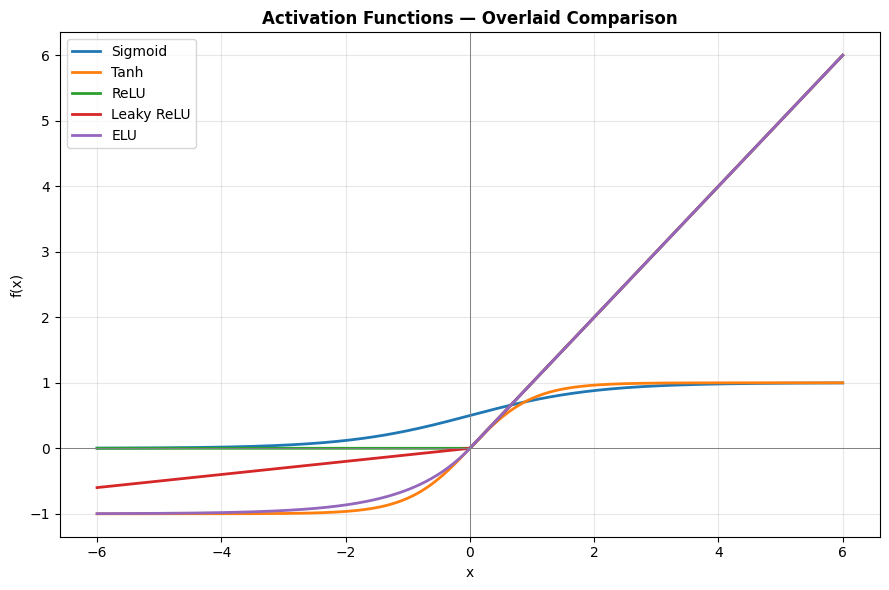

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.linspace(-6, 6, 400)

ax.plot(x, sigmoid(x), label="Sigmoid", linewidth=2)
ax.plot(x, tanh(x), label="Tanh", linewidth=2)
ax.plot(x, relu(x), label="ReLU", linewidth=2)
ax.plot(x, leaky_relu(x), label="Leaky ReLU", linewidth=2)
ax.plot(x, elu(x), label="ELU", linewidth=2)

ax.axhline(0, color="gray", linewidth=0.7)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_title("Activation Functions — Overlaid Comparison", fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("activation_overlay_output.png", dpi=150)
plt.show()


## Task 7 (Bonus) — ANN on the Breast Cancer Wisconsin Dataset

We train a simple ANN classifier, evaluate accuracy, and plot the training curves and confusion matrix.


In [9]:
data = load_breast_cancer()
X, y = data.data, data.target
print("Feature matrix shape:", X.shape)
print("Classes:", data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Feature matrix shape: (569, 30)
Classes: ['malignant' 'benign']
Train shape: (455, 30)  Test shape: (114, 30)


In [10]:
bc_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

bc_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = bc_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0,
)

print("Training complete.")


Training complete.


In [11]:
test_loss, test_acc = bc_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")


Test Accuracy: 0.9474
Test Loss:     0.1207


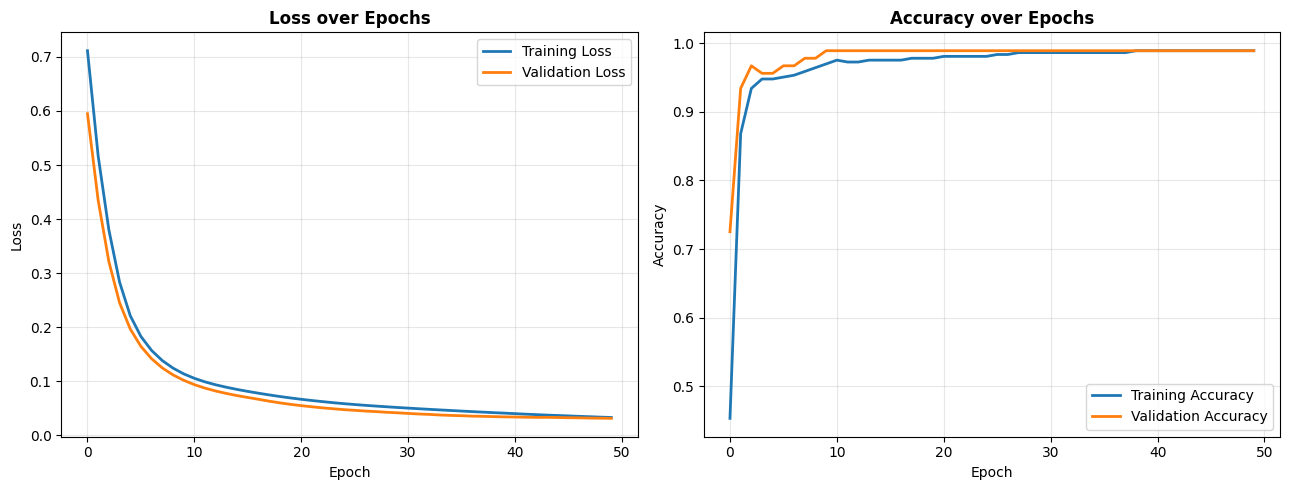

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Loss over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Training Accuracy", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[1].set_title("Accuracy over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_output.png", dpi=150)
plt.show()


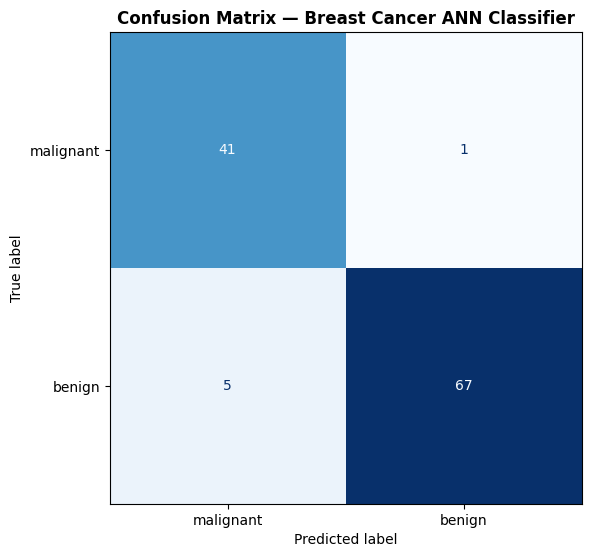

Final Accuracy: 0.9474


In [13]:
y_pred_prob = bc_model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Breast Cancer ANN Classifier", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_output.png", dpi=150)
plt.show()

print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
